# Milestone 2B.3 — End-to-end translucent camera proxy

**Debug proxy — not sequence-gen physics.** Canonical walkthrough of the transient M2B stack: face thickness → Beer–Lambert → beam field → `I_proxy`, with factor diagnostics.

Plan: [`plans/milestone_02/02b_translucent_camera_proxy_plan.md`](../../plans/milestone_02/02b_translucent_camera_proxy_plan.md). Prerequisite: `02b_1_illumination_basics.ipynb`, `02b_2_lambert_beer.ipynb`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from gummybear.geometry import inspect_stl
from gummybear.optics import PointLightConfig
from gummybear.rays.camera import PinholeCameraConfig, make_pinhole_rays
from gummybear_validation.helpers import compute_m2b_debug_proxy, print_m2b_face_fields
from gummybear_validation.plotting import plot_m2b_proxy_diagnostics


In [3]:
# 1. Mesh
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]
print(inspection["summary"])


{'vertices': 9083, 'faces': 18162, 'bbox_min': [-14.460152626037598, -9.669693946838379, -5.0], 'bbox_max': [12.224034309387207, 10.577157020568848, 10.0], 'bbox_size': [26.684186935424805, 20.246850967407227, 15.0], 'centroid': [-0.3784676994576298, -0.09824173923582938, 2.3279409780550253], 'area': 1601.5782018919901, 'volume': 4822.621783023175, 'is_watertight': True, 'is_winding_consistent': True, 'units': 'mm', 'source_path': 'cad/proto_bear.stl', 'stl_sha256': '82d4223bb5910aac1301016e3f1fe7cf8b59c4e8188a841ead8ecdb2d3ce6f29'}


In [4]:
# 2. Fixed pinhole (plan reference pose)
camera = PinholeCameraConfig(
    camera_position=(0.0, -40.0, 0.0),
    look_at=(0.0, 0.0, 0.0),
    up=(0.0, 0.0, 1.0),
    fov_deg=35.0,
    resolution=256,
)
rays = make_pinhole_rays(camera)
print("sample_shape:", rays.sample_shape)


sample_shape: (256, 256)


In [5]:
# 3. Point light (falloff="none" for easier first pass; try inverse_square later)
light = PointLightConfig(
    position=(0.0, 0.0, 30.0),
    intensity=1.0,
    falloff="none",
)
print("light:", light)


light: PointLightConfig(position=(0.0, 0.0, 30.0), intensity=1.0, falloff='none', r_min=1e-06)


In [6]:
# 4–6. Transient proxy pipeline (steps 4–6 in plan)
result = compute_m2b_debug_proxy(mesh, rays, light, mu=0.15, eps=1e-4)
print_m2b_face_fields(result.L_proxy, result.T_face, result.face_source_intensity)

field = result.field
print("valid pixels:", int(field.valid_mask.sum()))
print(
    "I_proxy min/max/mean:",
    result.I_proxy.min(),
    result.I_proxy.max(),
    result.I_proxy.mean(),
)


L_proxy: shape=(18162,), sum=172426.766695, min=0, max=15.6804981014, nnz=15071
T_face: shape=(18162,), sum=6534.43380604, min=0.0951715034774, max=1, nnz=18162
face_source_intensity: shape=(18162,), sum=18162, min=1, max=1, nnz=18162
valid pixels: 43813
I_proxy min/max/mean: 0.0 0.8248228868064972 0.17955999646982443


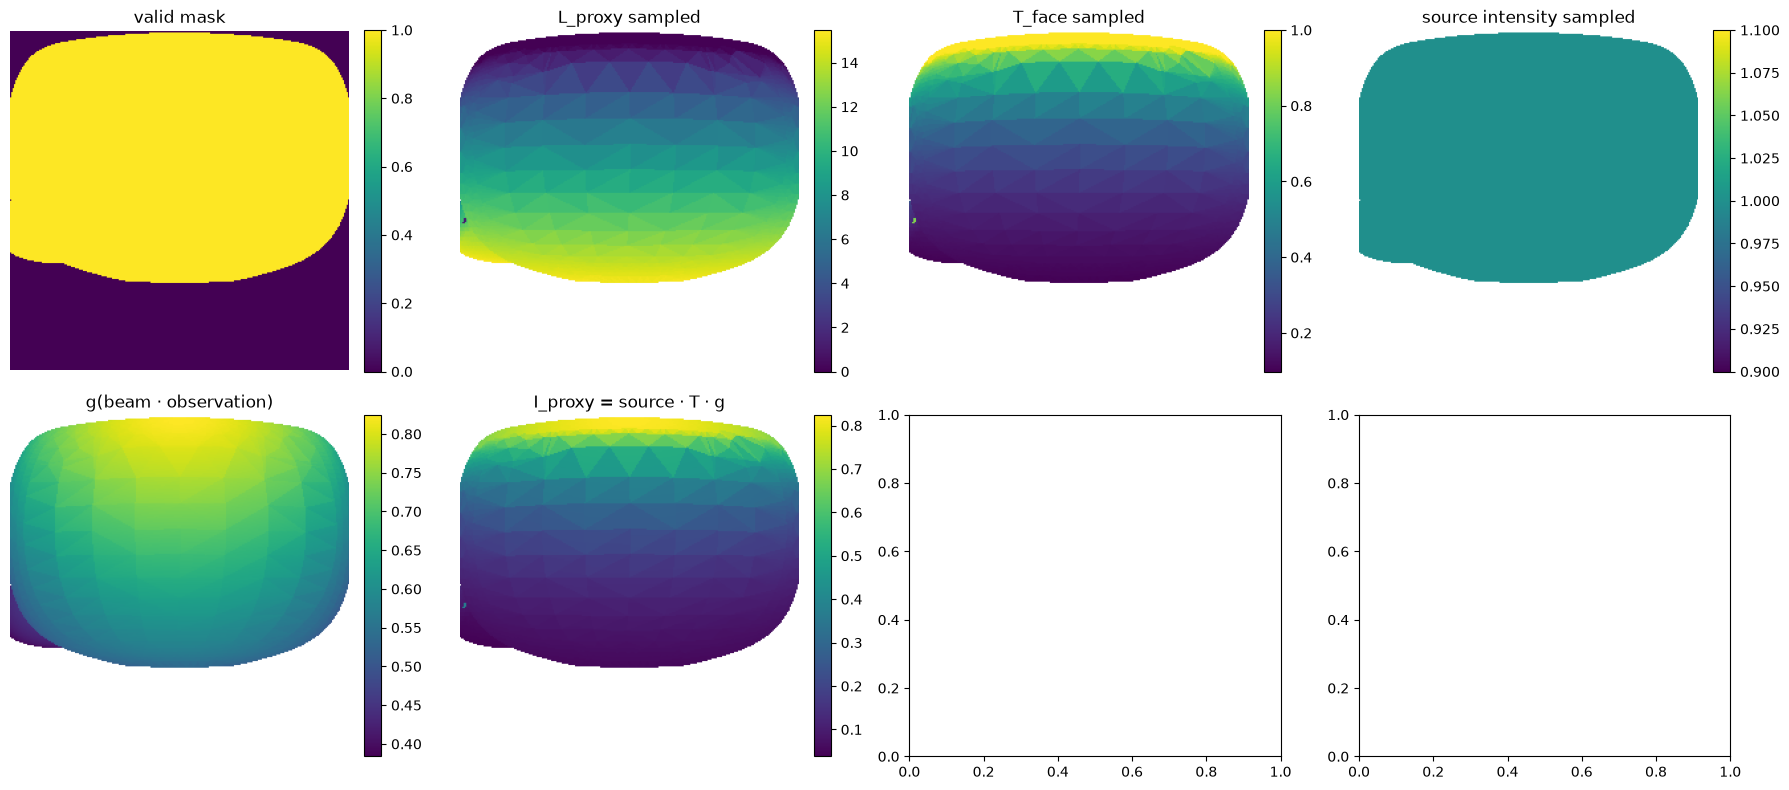

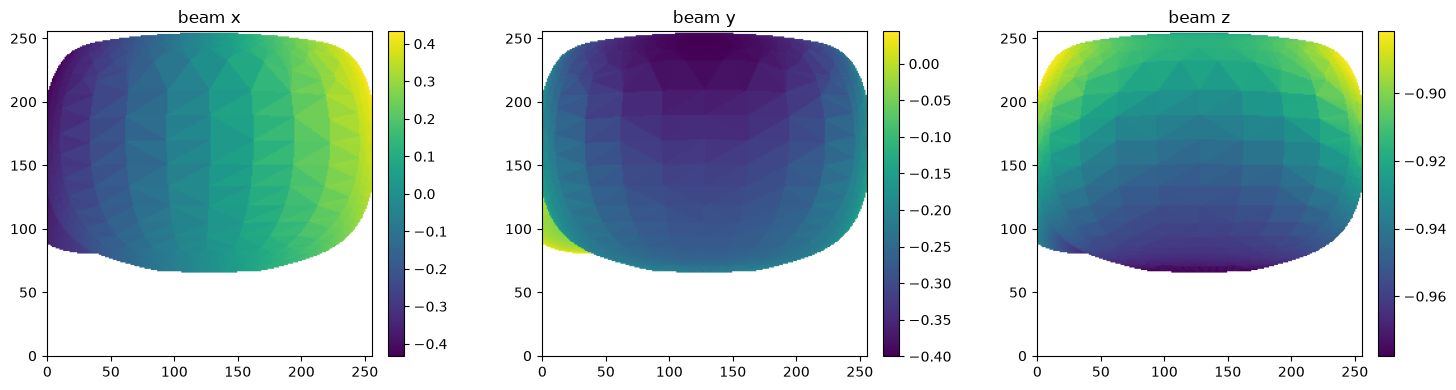

In [7]:
# Factor panel: mask, L/T/source samples, g(b·v), I_proxy, beam x/y (+ optional full row)
plot_m2b_proxy_diagnostics(
    field,
    result.L_proxy,
    result.T_face,
    result.face_source_intensity,
    result.I_proxy,
    show_beam_components="full",
)
